In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import os
import csv
import copy
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.layers import Input, Concatenate, Dropout, Dense, Lambda, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, InceptionV3, Xception
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from pytorch_grad_cam import LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
# Define constants
IMAGE_SIZE = (224, 224)  # Ensure this matches your dataset
NUM_CLASSES = 4  # Matches the 4 classes in class_names

# Load pre-trained models
model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))
inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))
xception_model = Xception(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))

# Create feature extractor models with global average pooling
resnet_features = GlobalAveragePooling2D()(model.output)  # Convert (None, 7, 7, 2048) to (None, 2048)
resnet_feature_extractor = Model(inputs=model.input, outputs=resnet_features)

# Adjust InceptionV3 to handle ResNet50-preprocessed inputs
inception_input = Input(shape=(*IMAGE_SIZE, 3))
inception_scaled = Lambda(lambda x: x / 127.5 - 1.0)(inception_input)  # Scale to [-1, 1]
inception_features = inception_model(inception_scaled)
inception_features = GlobalAveragePooling2D()(inception_features)  # Convert (None, 5, 5, 2048) to (None, 2048)
inception_feature_extractor = Model(inputs=inception_input, outputs=inception_features)

# Adjust Xception to handle ResNet50-preprocessed inputs
xception_input = Input(shape=(*IMAGE_SIZE, 3))
xception_scaled = Lambda(lambda x: x / 127.5 - 1.0)(xception_input)  # Scale to [-1, 1]
xception_features = xception_model(xception_scaled)
xception_features = GlobalAveragePooling2D()(xception_features)  # Convert (None, 7, 7, 2048) to (None, 2048)
xception_feature_extractor = Model(inputs=xception_input, outputs=xception_features)

# Freeze the feature extractors
resnet_feature_extractor.trainable = False
inception_feature_extractor.trainable = False
xception_feature_extractor.trainable = False

# Define a new input layer for the ensemble model
ensemble_input = Input(shape=(*IMAGE_SIZE, 3))

# Obtain feature representations from each model
resnet_features = resnet_feature_extractor(ensemble_input)
inception_features = inception_feature_extractor(ensemble_input)
xception_features = xception_feature_extractor(ensemble_input)

# Concatenate the feature vectors
merged_features = Concatenate()([resnet_features, inception_features, xception_features])  # Shape: (None, 6144)

# Add additional dense layers for fusion
fusion = Dense(512, activation='relu')(merged_features)
fusion = Dropout(0.5)(fusion)
ensemble_output = Dense(NUM_CLASSES, activation='softmax')(fusion)

# Define the hybrid model
hybrid_model = Model(inputs=ensemble_input, outputs=ensemble_output)

# Compile the hybrid model
hybrid_model.compile(optimizer=Adam(learning_rate=0.0001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Preprocess datasets for ResNet50
def preprocess_dataset(ds):
    return ds.map(lambda x, y: (preprocess_input(x), y))

train_ds = preprocess_dataset(train_ds)
val_ds = preprocess_dataset(val_ds)

# Define callbacks
hybrid_checkpoint_cb = ModelCheckpoint(
    filepath='/kaggle/working/hybrid_model_best.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=2
)
hybrid_csv_logger = CSVLogger('hybrid_model_training_log.csv', separator=',', append=False)

# Train the hybrid model
hybrid_history = hybrid_model.fit(train_ds, validation_data=val_ds, epochs=50,
                                 callbacks=[hybrid_checkpoint_cb, hybrid_csv_logger])

# Verify model and dataset
print("Hybrid model input shape:", hybrid_model.input_shape)
for images, labels in val_ds.take(1):
    print("Sample input image shape:", images[0:1].shape)
    print("Sample image min/max:", tf.reduce_min(images[0]).numpy(), tf.reduce_max(images[0]).numpy())
    print("Sample label shape:", labels[0].shape)
    break

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6547 - loss: 0.8499
Epoch 1: val_accuracy improved from -inf to 0.81771, saving model to /kaggle/working/hybrid_model_best.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 88s 256ms/step - accuracy: 0.6550 - loss: 0.8490 - val_accuracy: 0.8177 - val_loss: 0.4103
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7974 - loss: 0.4526
Epoch 2: val_accuracy improved from 0.81771 to 0.83368, saving model to /kaggle/working/hybrid_model_best.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 50s 209ms/step - accuracy: 0.7974 - loss: 0.4526 - val_accuracy: 0.8337 - val_loss: 0.3718
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8197 - loss: 0.4103
Epoch 3: val_accuracy did not improve from 0.83368
240/240 ━━━━━━━━━━━━━━━━━━━━ 49s 203ms/step - accuracy: 0.8197 - loss: 0.4103 - val_accuracy: 0.8323 - val_loss: 0.3611
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8310 - loss: 0.3741
Epoch 

In [ ]:
print("Hybrid model input shape:", hybrid_model.input_shape)
for images, labels in val_ds.take(1):
    print("Sample input image shape:", images[0:1].shape)
    print("Sample image min/max:", tf.reduce_min(images[0]).numpy(), tf.reduce_max(images[0]).numpy())
    print("Sample label shape:", labels[0].shape)
    break

Hybrid model input shape: (None, 224, 224, 3)
Sample input image shape: (1, 224, 224, 3)
Sample image min/max: -123.68 145.13754
Sample label shape: (4,)


In [ ]:
# Load best weights before evaluation (if needed)
hybrid_model.load_weights('/kaggle/working/hybrid_model_best.weights.h5')

# Evaluate the hybrid model on validation data
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(val_ds)
print(f"\nHybrid Model Evaluation:")
print(f"Loss: {hybrid_loss:.4f}")
print(f"Accuracy: {hybrid_accuracy * 100:.2f}%\n")

90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.9818 - loss: 0.0578

Hybrid Model Evaluation:
Loss: 0.1192
Accuracy: 96.25%



In [ ]:
# Generate predictions for the validation dataset
y_pred_prob = hybrid_model.predict(val_ds)  # Probability outputs
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert to class labels

# Extract true labels from validation dataset
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds])

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step

Classification Report:
                  precision    recall  f1-score   support

     NonDemented       1.00      0.99      0.99       719
VeryMildDemented       0.97      0.93      0.95       728
    MildDemented       0.91      0.97      0.94       728
ModerateDemented       0.98      0.97      0.97       705

        accuracy                           0.96      2880
       macro avg       0.96      0.96      0.96      2880
    weighted avg       0.96      0.96      0.96      2880



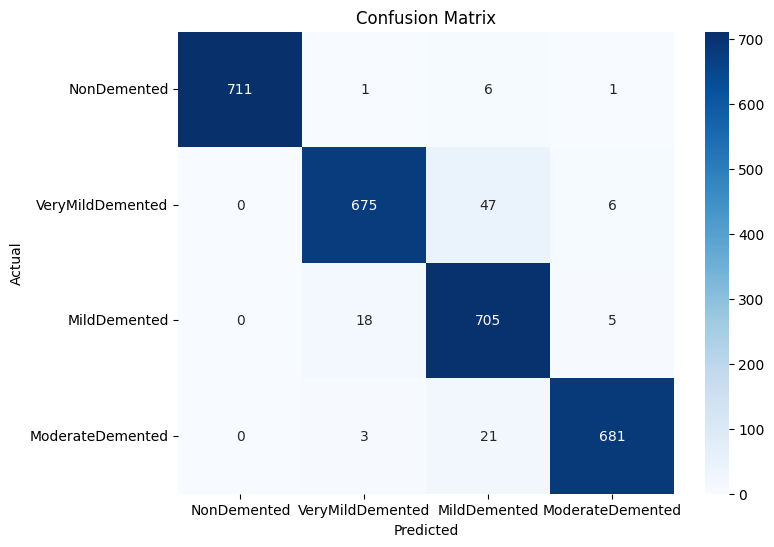

In [ ]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

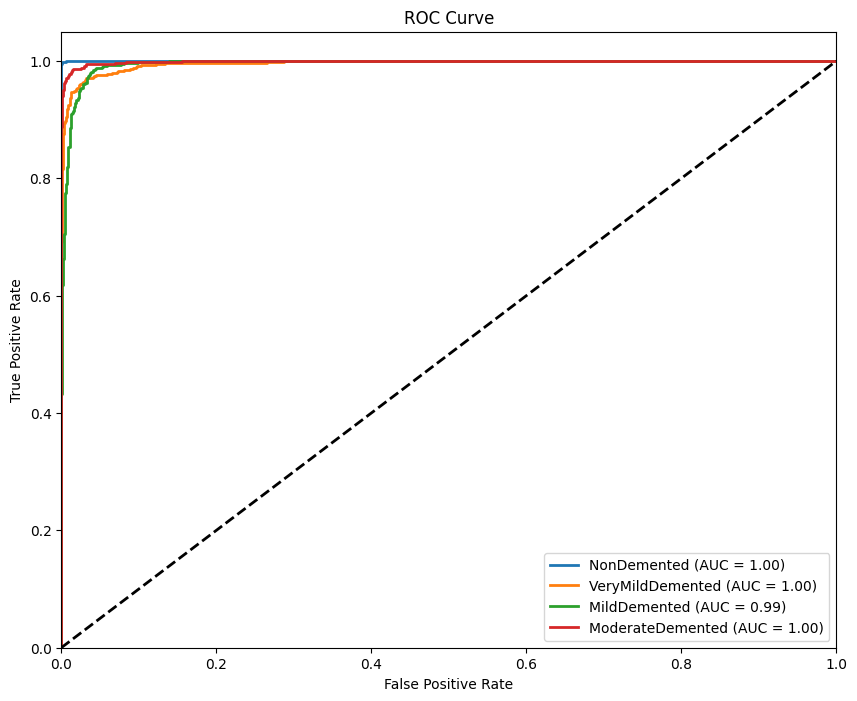

In [ ]:
# Compute ROC curves and AUC for each class
y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

Generating Styled ROC Curve...


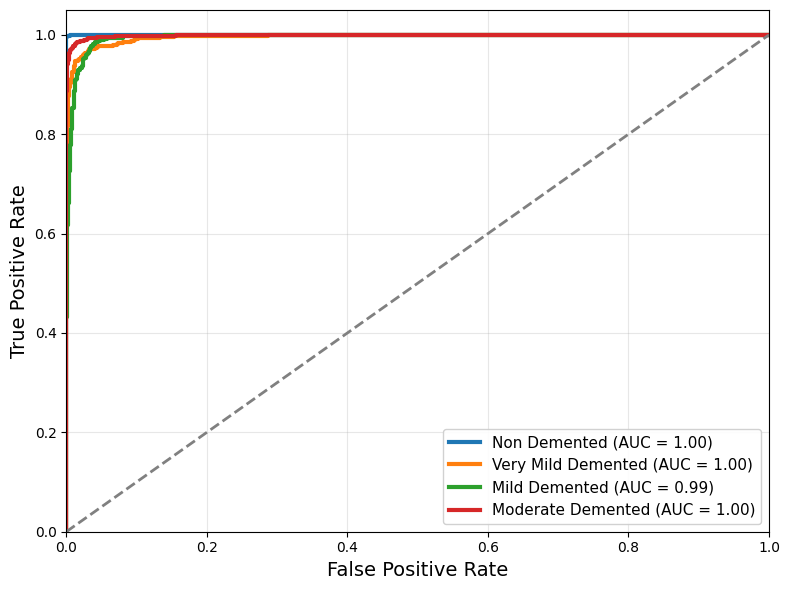

Generating Styled Precision-Recall Curve (PRC)...


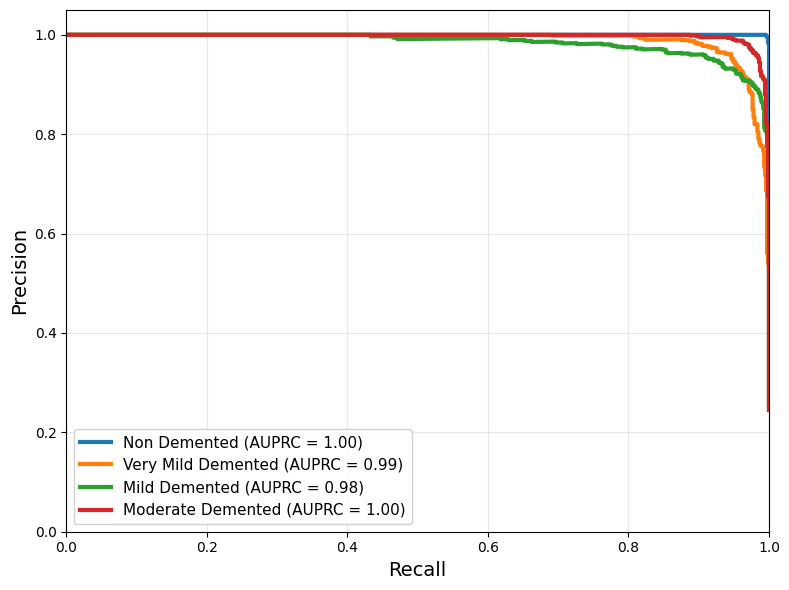

In [ ]:
# --- CONFIGURATION AND PLACEHOLDERS (Ensure these match your working environment) ---
CLASS_NAMES = ['Non Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']
N_CLASSES = len(CLASS_NAMES)
# Define consistent styles
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Consistent Color scheme
MODEL_NAME = "Multi-Class Model" # Use your actual model name

# Placeholder Data: Replace these with your actual model results
if 'y_true' not in locals() or 'y_pred_prob' not in locals():
    # Generate dummy data for a runnable example
    np.random.seed(42)
    N_SAMPLES = 100
    y_true = np.random.randint(0, N_CLASSES, N_SAMPLES)
    y_pred_prob = np.random.rand(N_SAMPLES, N_CLASSES)
    y_pred_prob = y_pred_prob / y_pred_prob.sum(axis=1)[:, np.newaxis]

# Calculate binarized true labels
y_true_binarized = label_binarize(y_true, classes=range(N_CLASSES))


# #################################################################
# 1. STANDALONE ROC Curve (Styled)
# #################################################################

print("Generating Styled ROC Curve...")

plt.figure(figsize=(8, 6)) # Consistent figure size (8x6)

for i in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc = calculate_auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=COLORS[i],
        lw=3, # Thicker line
        label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})' # Specific class names
    )

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2) # Styled random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Apply consistent font styling
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title(f'{MODEL_NAME} - ROC Curve', fontsize=16, fontweight='bold')

# Apply consistent legend and grid styling
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# #################################################################
# 2. STANDALONE Precision-Recall Curve (Styled)
# #################################################################

print("Generating Styled Precision-Recall Curve (PRC)...")

plt.figure(figsize=(8, 6)) # Consistent figure size (8x6)

for i in range(N_CLASSES):
    precision, recall, _ = precision_recall_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    # AUPRC calculation
    auprc = calculate_auc(recall, precision)
    plt.plot(
        recall, precision,
        color=COLORS[i],
        lw=3, # Thicker line
        label=f'{CLASS_NAMES[i]} (AUPRC = {auprc:.2f})' # Specific class names
    )

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Apply consistent font styling
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
#plt.title(f'{MODEL_NAME} - Precision-Recall Curve', fontsize=16, fontweight='bold')

# Apply consistent legend and grid styling
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Searching test set for correctly predicted images (Hybrid Model)...
Images found! Generating sharp LayerCAMs...


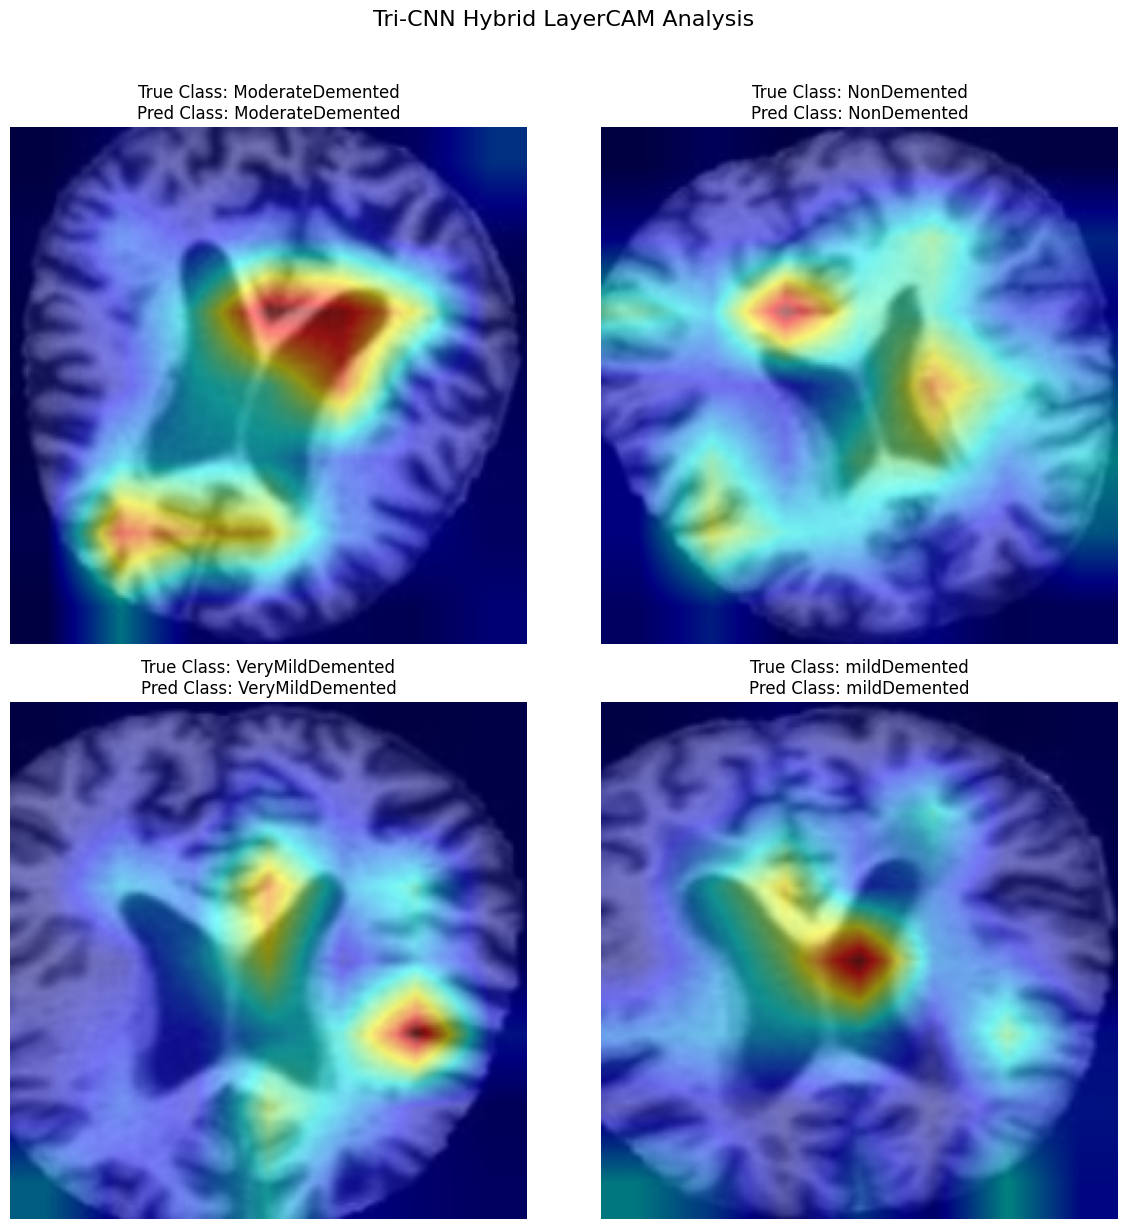

Saved high-resolution image to Hybrid_LayerCAM_Localized.png


In [ ]:
# 1. Target the final spatial layer of the ResNet branch
target_layers = [hybrid_model.resnet.layer4[-1]]
class_names = val_dataset.classes
found_classes = {}

print("Searching test set for correctly predicted images (Hybrid Model)...")
hybrid_model.eval()

# 2. Iterate through the validation loader
for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = hybrid_model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(labels)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        if true_label == pred_label and true_label not in found_classes:
            img_tensor = images[i].unsqueeze(0)

            # Un-normalize for human viewing
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
            rgb_img = images[i] * std + mean
            rgb_img = rgb_img.permute(1, 2, 0).cpu().numpy()
            rgb_img = np.clip(rgb_img, 0, 1)

            found_classes[true_label] = (img_tensor, rgb_img, class_names[true_label])

    if len(found_classes) == 4:
        break

print("Images found! Generating sharp LayerCAMs...")

# 3. Initialize LayerCAM (Notice: No reshape_transform needed for CNNs!)
cam = LayerCAM(
    model=hybrid_model,
    target_layers=target_layers
)

# 4. Create a 2x2 grid for the research paper figure
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Tri-CNN Hybrid LayerCAM Analysis", fontsize=16, y=1.02)
axes = axes.flatten()

# 5. Generate and plot the heatmap for each class
for idx, class_idx in enumerate(sorted(found_classes.keys())):
    img_tensor, rgb_img, class_name = found_classes[class_idx]

    targets = [ClassifierOutputTarget(class_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[idx].imshow(visualization)
    axes[idx].set_title(f"True Class: {class_name}\nPred Class: {class_name}", fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

fig.savefig('Hybrid_LayerCAM_Localized.png', dpi=300, bbox_inches='tight')
print("Saved high-resolution image to Hybrid_LayerCAM_Localized.png")